In [1]:
import numpy as np
import librosa
import soundfile as sf
import torch
import matplotlib.pyplot as plt
from main import init
import os
import torchaudio
from data import *
from main import *
from generate import adpcm_encode, adpcm_decode

/mnt/nvme0/home/utbt/KhoaVM/npp_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def change_length(x):
        max_length = 1048064
        n = x.shape[0]

        if n > max_length:
            x = x[:max_length]
        
        elif n < max_length:
            pad_size = max_length - n
            return np.pad(array=x, pad_width=(0, pad_size), mode='constant', constant_values=0)
        
        return x

def spec_to_audio(spec_db, n_fft=1022, hop_length=512):
    spec = librosa.db_to_amplitude(spec_db)

    audio = librosa.griffinlim(
        spec,
        n_fft=n_fft,
        hop_length=hop_length,
        n_iter=256,
    )

    return audio


In [3]:
IRMAS_PATH_CP = './checkpoints/IRMAS_checkpoints'
LIBRISPEECH_PATH_CP = './checkpoints/LibriSpeech_checkpoints'

MODEL_NAME = 'Unet'
DATASET_NAME = 'IRMAS'
BATCH_SIZE = 1
NUM_WORKERS = 4
PIN_MEMORY= True
DEVICE = 'cuda'

EPOCHS = 50
LR = 1e-4

device, model, train_loader, val_loader, test_loader, checkpoint, optimizer = init(model_name=MODEL_NAME, 
                                                                                        dataset_name=DATASET_NAME, 
                                                                                        batch_size=BATCH_SIZE, 
                                                                                        num_workers=NUM_WORKERS, 
                                                                                        pin_memory=PIN_MEMORY,
                                                                                        lr=LR,
                                                                                        device=DEVICE)


model.load_state_dict(torch.load(checkpoint))


device: cuda


/tmp/ipykernel_1276578/1830437261.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint))


<All keys matched successfully>

In [4]:
data = iter(test_loader)

i = 0


x = data._dataset[i][0].unsqueeze(0)
y = data._dataset[i][1].unsqueeze(0)

x_spec = x.squeeze()
y_spec = y.squeeze()

In [5]:
x = x.to(device)
y = y.to(device)
out = model(x)

In [6]:
x_spec = x.cpu().detach().numpy().squeeze(0).squeeze(0)
y_spec = y.cpu().detach().numpy().squeeze(0).squeeze(0)
out_spec = out.cpu().detach().numpy().squeeze(0).squeeze(0)

In [7]:
out_waveform = spec_to_audio(out_spec, n_fft=1022, hop_length=512)

In [8]:
x_waveform = spec_to_audio(x_spec, n_fft=1022, hop_length=512)

In [9]:
y_waveform = spec_to_audio(y_spec, n_fft=1022, hop_length=512)

Text(0.5, 1.0, 'output')

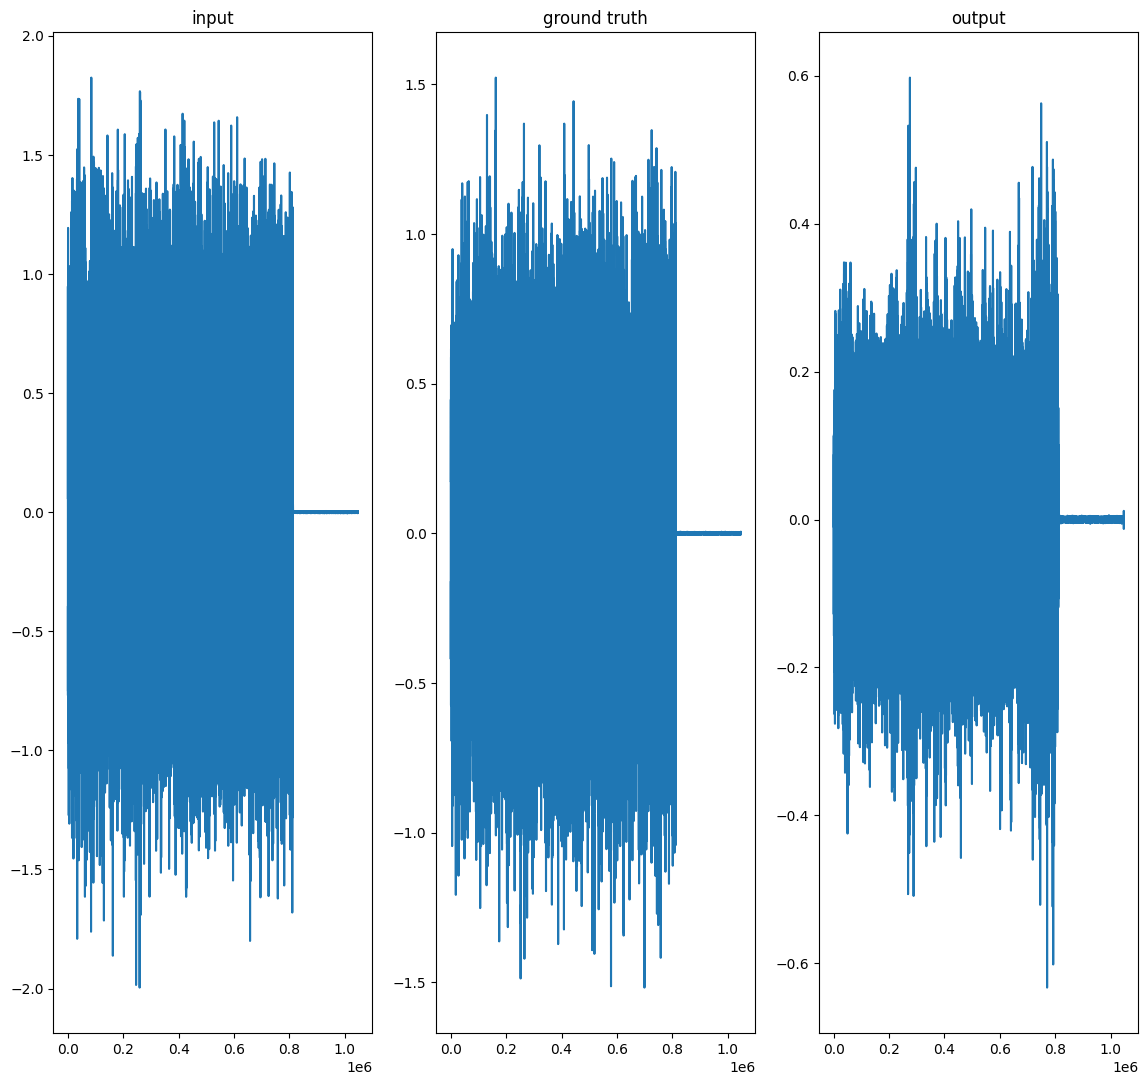

In [10]:
plt.figure(figsize=(14, 13))
plt.subplot(1, 3, 1)
plt.plot(x_waveform)
plt.title('input')

plt.subplot(1, 3, 2)
plt.plot(y_waveform)
plt.title('ground truth')

plt.subplot(1, 3, 3)
plt.plot(out_waveform)
plt.title('output')


In [11]:
sf.write("output.wav", out_waveform, 64000)
sf.write("input.wav", x_waveform, 64000)
sf.write("ground_truth.wav", y_waveform, 64000)

In [12]:
x_waveform.shape

(1048064,)

In [13]:
out_waveform.shape

(1048064,)

Text(0.5, 1.0, 'output')

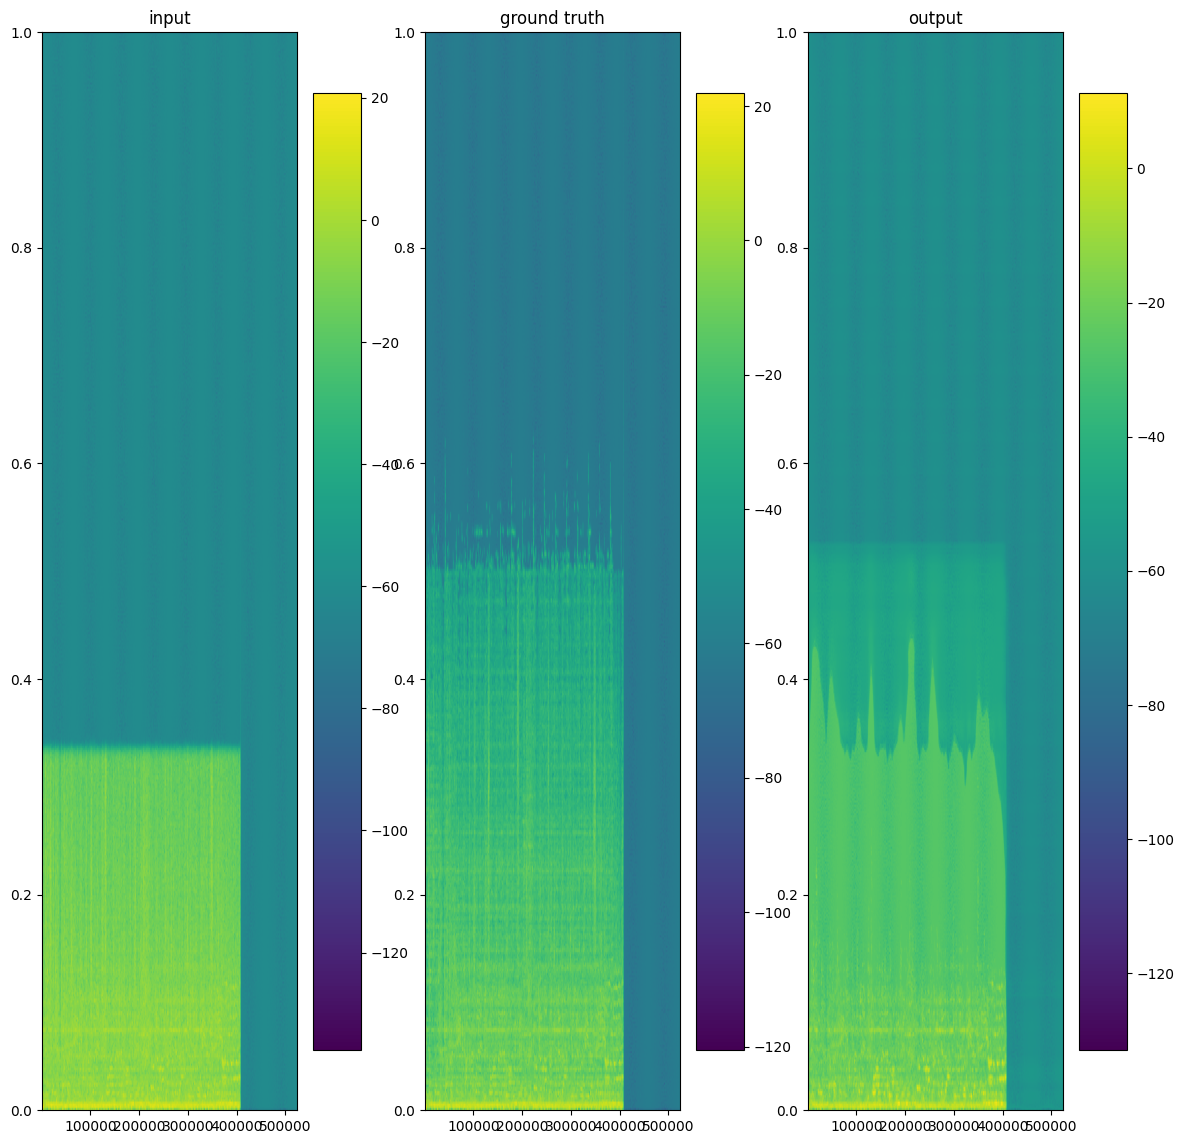

In [14]:
plt.figure(figsize=(14, 14))
plt.subplot(1, 3, 1)
plt.specgram(x_waveform, NFFT=1022, noverlap=512)
plt.colorbar()
plt.title('input')
plt.subplot(1, 3, 2)
plt.specgram(y_waveform, NFFT=1022, noverlap=512)
plt.colorbar()
plt.title('ground truth')

plt.subplot(1, 3, 3)
plt.specgram(out_waveform, NFFT=1022, noverlap=512)
plt.colorbar()
plt.title('output')
